In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.preprocessing import OneHotEncoder

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [6]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [7]:
from xgboost import XGBRegressor

In [8]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [9]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [10]:
from sklearn.pipeline import Pipeline

In [11]:
import joblib

In [12]:
import warnings
warnings.filterwarnings(action = "ignore")

In [13]:
car_df = pd.read_csv("cardekho_dataset.csv")

In [14]:
car_df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [15]:
car_df.drop(["Unnamed: 0", "model"], axis = 1, inplace = True)

In [16]:
car_df.isna().sum()

car_name             0
brand                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [17]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  object 
 1   brand              15411 non-null  object 
 2   vehicle_age        15411 non-null  int64  
 3   km_driven          15411 non-null  int64  
 4   seller_type        15411 non-null  object 
 5   fuel_type          15411 non-null  object 
 6   transmission_type  15411 non-null  object 
 7   mileage            15411 non-null  float64
 8   engine             15411 non-null  int64  
 9   max_power          15411 non-null  float64
 10  seats              15411 non-null  int64  
 11  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 1.4+ MB


In [18]:
car_df["brand"].value_counts().head(10)

brand
Maruti        4992
Hyundai       2982
Honda         1485
Mahindra      1011
Toyota         793
Ford           790
Volkswagen     620
Renault        536
BMW            439
Tata           430
Name: count, dtype: int64

In [19]:
car_df["car_name"].value_counts().head()

car_name
Hyundai i20           906
Maruti Swift Dzire    890
Maruti Swift          781
Maruti Alto           778
Honda City            757
Name: count, dtype: int64

#### Not likely anyone would be willing to buy a car older than 15 years due to the current emission norms.

<Axes: xlabel='vehicle_age', ylabel='Count'>

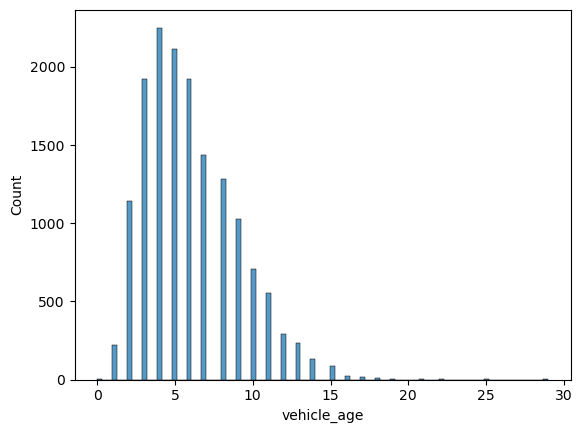

In [20]:
sns.histplot(data=car_df, x='vehicle_age')


#### Presence of extreme maximum outliers for the "km_driven" feature

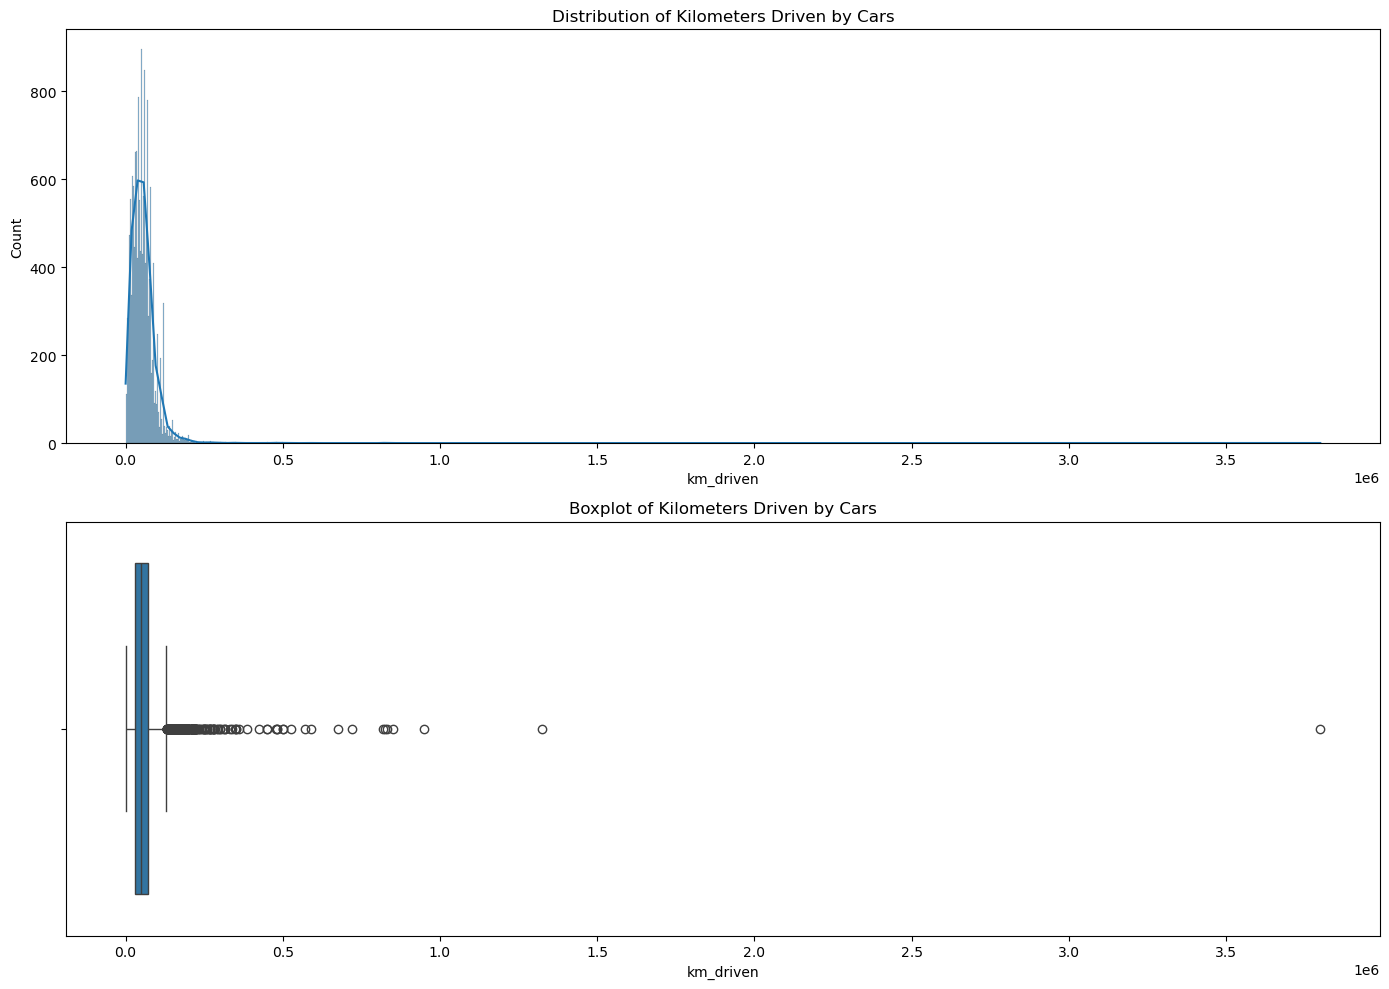

In [21]:
fig, ax = plt.subplots(2, 1, figsize=(14,10))  # 2 rows, 1 column

# Histogram
sns.histplot(data=car_df, x='km_driven', ax=ax[0], kde=True)
ax[0].set_title('Distribution of Kilometers Driven by Cars')

# Boxplot
sns.boxplot(x='km_driven', data=car_df, ax=ax[1])
ax[1].set_title('Boxplot of Kilometers Driven by Cars')

plt.tight_layout()
plt.show()

#### Highly improbable for a car to be driven for more than 500000. Especially in Indian conditions and when vehicle age is less than 10 years. 

In [22]:
car_df[car_df["km_driven"]>500000]

,car_name,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
2731,Ford Figo,Ford,10,570000,Dealer,Petrol,Manual,15.60,1196,70.00,5,200000
4532,Renault Duster,Renault,4,850000,Dealer,Diesel,Manual,19.87,1461,83.80,5,850000
6712,Volkswagen Vento,Volkswagen,9,830000,Dealer,Diesel,Manual,20.54,1598,103.60,5,380000
7323,Ford Ecosport,Ford,6,720000,Dealer,Diesel,Manual,22.70,1498,89.84,5,675000
7534,Toyota Fortuner,Toyota,2,590000,Dealer,Diesel,Manual,14.24,2755,174.50,7,2850000
8772,Toyota Innova,Toyota,6,950000,Dealer,Diesel,Manual,12.99,2494,100.60,7,950000
9170,Skoda Rapid,Skoda,5,675000,Dealer,Diesel,Automatic,21.66,1498,103.52,5,675000
10384,Honda Jazz,Honda,4,525000,Dealer,Petrol,Manual,18.70,1199,88.70,5,525000
10838,Hyundai Creta,Hyundai,6,825000,Dealer,Diesel,Manual,19.67,1582,126.20,5,825000
11615,Volkswagen Polo,Volkswagen,5,820000,Dealer,Petrol,Automatic,17.21,1197,103.50,5,695000


In [23]:
cleaned_car_df = car_df[(car_df["km_driven"] < 500000) & (car_df["vehicle_age"] <= 15)]

In [24]:
cleaned_car_df.head()

,car_name,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [25]:
cleaned_car_df["seller_type"].value_counts()

seller_type
Dealer              9510
Individual          5650
Trustmark Dealer     173
Name: count, dtype: int64

In [26]:
cleaned_car_df["fuel_type"].value_counts()

fuel_type
Petrol      7584
Diesel      7400
CNG          301
LPG           44
Electric       4
Name: count, dtype: int64

#### Checking if valid entries are made for the LPG fuel type vehicles

In [27]:
cleaned_car_df[cleaned_car_df["fuel_type"]=="LPG"].head()

,car_name,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
135,Maruti Wagon R,Maruti,9,57413,Individual,LPG,Manual,14.40,998,61.7,5,270000
842,Maruti Wagon R,Maruti,12,120000,Individual,LPG,Manual,17.30,1061,57.5,5,110000
1287,Maruti Wagon R,Maruti,9,120000,Individual,LPG,Manual,26.20,998,58.2,5,260000
1939,Hyundai Santro,Hyundai,11,35000,Dealer,LPG,Manual,13.45,1086,62.1,5,230000
3345,Maruti Wagon R,Maruti,14,68128,Dealer,LPG,Manual,17.30,1061,57.5,5,148000


#### Toyota Camry is actually a hybrid/petrol and not Electric. But doesn't make any difference to our analysis.

In [28]:
cleaned_car_df[cleaned_car_df["fuel_type"]=="Electric"]

,car_name,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
1997,Toyota Camry,Toyota,6,49500,Dealer,Electric,Automatic,19.16,2494,157.7,5,1850000
11630,Toyota Camry,Toyota,6,60000,Individual,Electric,Automatic,19.16,2494,157.7,5,2000000
14323,Toyota Camry,Toyota,5,85000,Dealer,Electric,Automatic,19.16,2494,157.7,5,1865000
14600,Toyota Camry,Toyota,6,64000,Dealer,Electric,Automatic,19.16,2494,157.7,5,1699000


In [29]:
cleaned_car_df["fuel_type"].replace("Electric", "Hybrid", inplace=True)

In [30]:
cleaned_car_df["fuel_type"].value_counts()

fuel_type
Petrol    7584
Diesel    7400
CNG        301
LPG         44
Hybrid       4
Name: count, dtype: int64

#### Manual cars dominate the market due to the low-maintanence cost and a smaller up-front payment

In [31]:
cleaned_car_df["transmission_type"].value_counts()

transmission_type
Manual       12158
Automatic     3175
Name: count, dtype: int64

#### Unusual to see a vehicle have an mileage of above 30

<Axes: xlabel='mileage', ylabel='Count'>

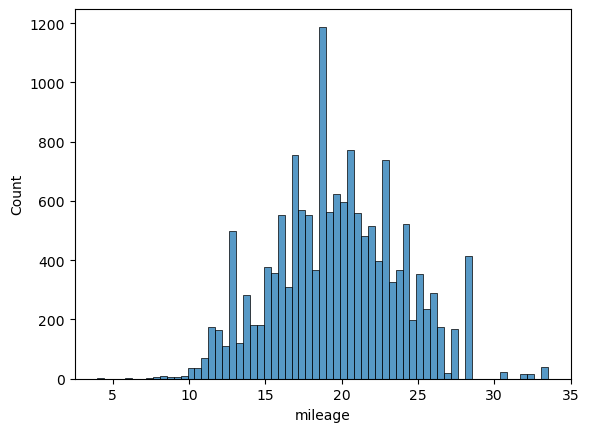

In [32]:
sns.histplot(data=cleaned_car_df, x='mileage')

#### Vehicles with over 30 mileage are of CNG fuel type. This is understandable. 

In [33]:
cleaned_car_df[(cleaned_car_df["mileage"] > 30)].head()

,car_name,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
169,Maruti Wagon R,Maruti,3,52000,Dealer,CNG,Manual,33.54,998,67.04,5,435000
182,Maruti Wagon R,Maruti,8,64000,Dealer,CNG,Manual,33.54,998,67.04,5,270000
317,Maruti Celerio,Maruti,3,28000,Dealer,CNG,Manual,31.79,998,58.33,5,455000
422,Maruti Alto,Maruti,5,45000,Dealer,CNG,Manual,30.46,796,47.30,5,350000
480,Maruti Alto,Maruti,5,42000,Dealer,CNG,Manual,33.44,796,40.30,4,260000


In [34]:
cleaned_car_df[(cleaned_car_df["mileage"] > 30) & (cleaned_car_df["fuel_type"] != "CNG")]

,car_name,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price


#### Luxury Cars with mileage less than 10

In [35]:
cleaned_car_df[(cleaned_car_df["mileage"] < 10)].head()

,car_name,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
318,Land Rover Rover,Land Rover,3,25000,Individual,Petrol,Automatic,9.17,2995,335.25,7,6200000
646,Jeep Wrangler,Jeep,4,40000,Dealer,Petrol,Automatic,9.50,3604,280.00,5,4875000
973,BMW 7,BMW,13,70000,Dealer,Petrol,Automatic,8.45,2979,321.00,5,750000
1041,BMW 6,BMW,6,25000,Dealer,Diesel,Automatic,9.52,2993,313.00,4,4490000
1172,Bentley Continental,Bentley,9,9000,Dealer,Petrol,Automatic,9.50,5998,626.00,4,14500000


#### Engine and Power Analysis

<Axes: xlabel='engine', ylabel='Count'>

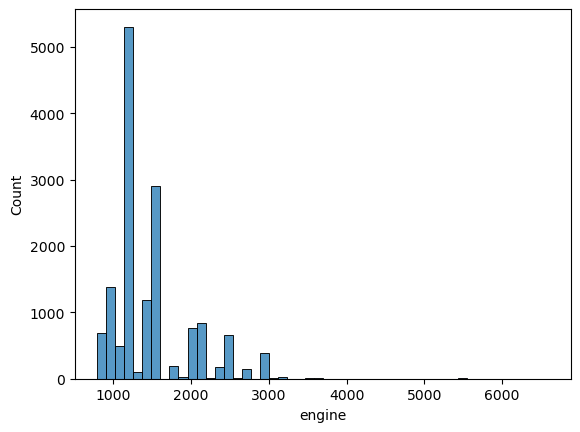

In [36]:
sns.histplot(data=cleaned_car_df, x='engine', bins = 50)

In [37]:
cleaned_car_df["engine"].min()

793

In [38]:
cleaned_car_df[cleaned_car_df["engine"] > 3000].head()

,car_name,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
129,Ford Endeavour,Ford,3,11387,Individual,Diesel,Automatic,10.91,3198,197.0,7,2900000
476,Ford Endeavour,Ford,4,62876,Dealer,Diesel,Automatic,10.91,3198,197.0,7,2875000
646,Jeep Wrangler,Jeep,4,40000,Dealer,Petrol,Automatic,9.50,3604,280.0,5,4875000
937,Audi Q7,Audi,10,65000,Dealer,Diesel,Automatic,11.33,4134,335.2,7,1890000
1172,Bentley Continental,Bentley,9,9000,Dealer,Petrol,Automatic,9.50,5998,626.0,4,14500000


<Axes: xlabel='max_power', ylabel='Count'>

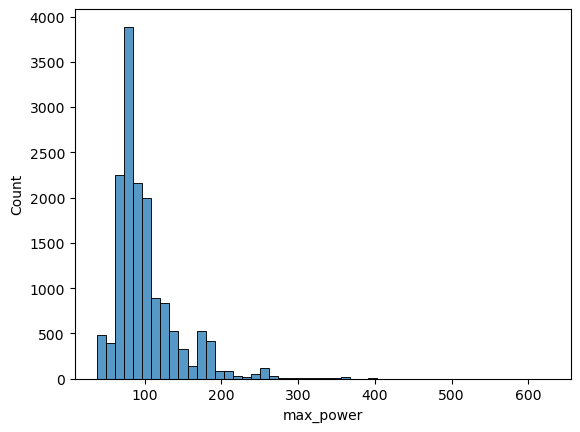

In [39]:
sns.histplot(data=cleaned_car_df, x='max_power', bins = 50)

In [40]:
cleaned_car_df["max_power"].min()

38.4

In [41]:
cleaned_car_df[cleaned_car_df["max_power"] < 40]

,car_name,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
1658,Maruti Alto,Maruti,9,53800,Dealer,CNG,Manual,26.83,796,38.4,5,235000
3295,Maruti Alto,Maruti,11,11000,Dealer,CNG,Manual,26.83,796,38.4,5,185000
8549,Maruti Alto,Maruti,11,80000,Dealer,CNG,Manual,26.83,796,38.4,5,150000
8911,Maruti Alto,Maruti,11,72000,Individual,CNG,Manual,26.83,796,38.4,5,125000
11159,Maruti Alto,Maruti,10,57000,Dealer,CNG,Manual,26.83,796,38.4,5,172000


In [42]:
cleaned_car_df[cleaned_car_df["max_power"] > 400].head()

,car_name,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
1172,Bentley Continental,Bentley,9,9000,Dealer,Petrol,Automatic,9.5,5998,626.0,4,14500000
1209,Porsche Cayenne,Porsche,4,36000,Dealer,Petrol,Automatic,12.5,3604,420.0,5,7800000
3799,Ferrari GTC4Lusso,Ferrari,2,3800,Dealer,Petrol,Automatic,4.0,3855,601.0,4,39500000
9190,Porsche Cayenne,Porsche,12,126000,Individual,Petrol,Automatic,8.5,4806,500.0,5,2000000
9364,Porsche Cayenne,Porsche,4,24000,Dealer,Petrol,Automatic,12.5,3604,440.0,5,11100000


#### Analsyis on number of seats in the car

In [43]:
cleaned_car_df["seats"].max(), cleaned_car_df["seats"].min()

(9, 0)

#### Invalid Entry as a car can't have 0 seats.

In [44]:
cleaned_car_df[cleaned_car_df["seats"] == 0]

,car_name,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
12619,Nissan Kicks,Nissan,2,10000,Individual,Diesel,Manual,19.39,1461,108.49,0,1154000


In [45]:
cleaned_car_df[cleaned_car_df["seats"] == 9].head()

,car_name,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
760,Mahindra Scorpio,Mahindra,7,120000,Individual,Diesel,Manual,15.40,2523,75.0,9,750000
924,Mahindra Bolero,Mahindra,4,80000,Individual,Diesel,Manual,15.96,2523,63.0,9,600000
989,Mahindra Scorpio,Mahindra,13,120000,Individual,Diesel,Manual,10.50,2609,120.0,9,300000
1148,Mahindra Scorpio,Mahindra,9,110000,Individual,Diesel,Manual,12.05,2179,120.0,9,600000
1266,Mahindra Scorpio,Mahindra,6,80000,Individual,Diesel,Manual,15.40,2523,75.0,9,800000


#### Nissan Kicks has 5 seats in all of its variants. We will change the previous entry.

In [46]:
cleaned_car_df[cleaned_car_df["car_name"] == "Nissan Kicks"].head()

,car_name,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
1259,Nissan Kicks,Nissan,1,15000,Individual,Petrol,Manual,14.23,1330,153.87,5,1000000
2485,Nissan Kicks,Nissan,1,7500,Individual,Diesel,Manual,20.45,1461,108.50,5,850000
3111,Nissan Kicks,Nissan,2,4000,Dealer,Petrol,Manual,14.23,1498,104.55,5,890000
4937,Nissan Kicks,Nissan,2,40000,Individual,Diesel,Manual,19.39,1461,108.00,5,1200000
9645,Nissan Kicks,Nissan,2,11687,Trustmark Dealer,Petrol,Manual,14.23,1498,104.55,5,880000


In [47]:
cleaned_car_df.loc[cleaned_car_df["car_name"] == "Nissan Kicks", "seats"] = 5

#### Converting the price into Lakhs for better readability

In [48]:
cleaned_car_df.loc[:, "selling_price_in_lakhs"] = cleaned_car_df["selling_price"] / 100000

In [49]:
cleaned_car_df.head()

,car_name,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,selling_price_in_lakhs
0,Maruti Alto,Maruti,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000,1.20
1,Hyundai Grand,Hyundai,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000,5.50
2,Hyundai i20,Hyundai,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000,2.15
3,Maruti Alto,Maruti,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000,2.26
4,Ford Ecosport,Ford,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000,5.70


In [50]:
cleaned_car_df.drop(["selling_price"], axis = 1, inplace = True)

<Axes: xlabel='selling_price_in_lakhs', ylabel='Count'>

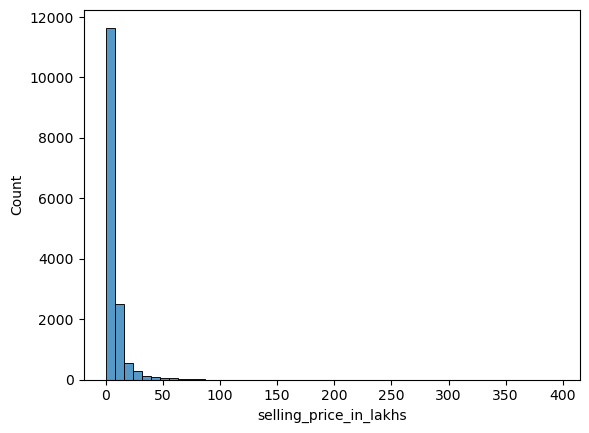

In [51]:
sns.histplot(data=cleaned_car_df, x='selling_price_in_lakhs', bins = 50)

In [52]:
cleaned_car_df[cleaned_car_df["selling_price_in_lakhs"] > 100]

,car_name,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price_in_lakhs
1172,Bentley Continental,Bentley,9,9000,Dealer,Petrol,Automatic,9.50,5998,626.00,4,145.0
1888,Mercedes-Benz S-Class,Mercedes-Benz,5,41000,Dealer,Petrol,Automatic,7.81,5461,362.90,5,110.0
3799,Ferrari GTC4Lusso,Ferrari,2,3800,Dealer,Petrol,Automatic,4.00,3855,601.00,4,395.0
9364,Porsche Cayenne,Porsche,4,24000,Dealer,Petrol,Automatic,12.50,3604,440.00,5,111.0
9722,Mercedes-Benz S-Class,Mercedes-Benz,3,4000,Dealer,Petrol,Automatic,7.81,4663,459.00,4,130.0
10969,Rolls-Royce Ghost,Rolls-Royce,4,5000,Individual,Petrol,Automatic,10.20,6592,563.00,4,242.0
10989,Mercedes-Benz S-Class,Mercedes-Benz,2,18000,Dealer,Petrol,Automatic,7.81,2996,362.07,5,110.0


In [53]:
cleaned_car_df[cleaned_car_df["selling_price_in_lakhs"] < 0.80].head()

,car_name,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price_in_lakhs
2966,Maruti Alto,Maruti,15,80000,Individual,Petrol,Manual,19.70,796,46.30,5,0.60
4823,Maruti Alto,Maruti,15,100000,Individual,Petrol,Manual,19.70,796,46.30,5,0.62
7302,Tata Safari,Tata,14,80000,Individual,Petrol,Manual,12.00,2092,127.00,7,0.70
7930,Maruti Wagon R,Maruti,15,45000,Dealer,Petrol,Manual,21.79,998,67.05,5,0.55
7958,Maruti Alto,Maruti,15,70000,Individual,Petrol,Manual,19.70,796,46.30,5,0.70


#### Invalid Entry for Vehicle Age

In [54]:
cleaned_car_df[cleaned_car_df["vehicle_age"]==0]

,car_name,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price_in_lakhs
5078,Maruti Ignis,Maruti,0,5000,Individual,Petrol,Manual,20.89,1197,81.80,5,5.5
7789,Mahindra KUV,Mahindra,0,30000,Individual,Petrol,Manual,18.15,1198,82.00,6,4.0
10315,BMW 5,BMW,0,2000,Dealer,Diesel,Automatic,22.48,1995,187.74,5,48.5
11486,BMW 5,BMW,0,2000,Dealer,Diesel,Automatic,22.48,1995,187.74,5,48.5
12157,Maruti S-Presso,Maruti,0,5000,Individual,Petrol,Manual,21.70,998,67.00,5,5.0


In [55]:
cleaned_car_df["vehicle_age"] = cleaned_car_df["vehicle_age"].replace(0, 1)

#### Engineering features to give the model a better understanding of features

In [56]:
cleaned_car_df["km_driven_per_year"] = round(cleaned_car_df["km_driven"] / cleaned_car_df["vehicle_age"], 0)

In [57]:
cleaned_car_df["power_to_engine_ratio"] = round(cleaned_car_df["max_power"] * 1000 / cleaned_car_df["engine"], 2) 
# as engine figures are in cc and not litres

In [58]:
cleaned_car_df.head()

,car_name,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price_in_lakhs,km_driven_per_year,power_to_engine_ratio
0,Maruti Alto,Maruti,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,1.20,13333.0,58.17
1,Hyundai Grand,Hyundai,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,5.50,4000.0,68.50
2,Hyundai i20,Hyundai,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,2.15,5455.0,66.83
3,Maruti Alto,Maruti,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,2.26,4111.0,67.23
4,Ford Ecosport,Ford,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,5.70,5000.0,65.81


#### Getting the skew values for all of the numerical columns

In [59]:
numerical_columns = cleaned_car_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_columns

['vehicle_age',
 'km_driven',
 'mileage',
 'engine',
 'max_power',
 'seats',
 'selling_price_in_lakhs',
 'km_driven_per_year',
 'power_to_engine_ratio']

In [60]:
num_col_to_skew = {}

In [61]:
for num_col in numerical_columns:
    num_col_to_skew[num_col] = cleaned_car_df[num_col].skew().round(4)

In [62]:
skew_df = pd.DataFrame.from_dict(num_col_to_skew, orient='index', columns=['Value'])

In [63]:
skew_df

,Value
vehicle_age,0.6808
km_driven,2.0979
mileage,0.1044
engine,1.6737
max_power,2.4920
seats,2.0912
selling_price_in_lakhs,10.0543
km_driven_per_year,3.5943
power_to_engine_ratio,0.3319


#### Normalising skewed columns

In [64]:
log_cols = [
    "km_driven",
    "engine",
    "max_power",
    "km_driven_per_year",
    "selling_price_in_lakhs"
]

for col in log_cols:
    cleaned_car_df[col] = np.log1p(cleaned_car_df[col]).round(4)

#### Seats is a categorical feature

In [65]:
cleaned_car_df["seats"] = cleaned_car_df["seats"].astype(str)

In [66]:
cleaned_car_df.head()

,car_name,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price_in_lakhs,km_driven_per_year,power_to_engine_ratio
0,Maruti Alto,Maruti,9,11.6953,Individual,Petrol,Manual,19.70,6.6809,3.8565,5,0.7885,9.4981,58.17
1,Hyundai Grand,Hyundai,5,9.9035,Individual,Petrol,Manual,18.90,7.0884,4.4188,5,1.8718,8.2943,68.50
2,Hyundai i20,Hyundai,11,11.0021,Individual,Petrol,Manual,17.00,7.0884,4.3944,5,1.1474,8.6045,66.83
3,Maruti Alto,Maruti,9,10.5187,Individual,Petrol,Manual,20.92,6.9068,4.2210,5,1.1817,8.3217,67.23
4,Ford Ecosport,Ford,6,10.3090,Dealer,Diesel,Manual,22.77,7.3126,4.6011,5,1.9021,8.5174,65.81


#### One Hot Encoding all of the categorical columns

In [67]:
categorical_columns = cleaned_car_df.select_dtypes(include=['object']).columns.tolist()

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

one_hot_encoded = encoder.fit_transform(cleaned_car_df[categorical_columns])

one_hot_df = pd.DataFrame(
    one_hot_encoded,
    columns=encoder.get_feature_names_out(categorical_columns),
    index=cleaned_car_df.index
)

df_encoded = pd.concat([cleaned_car_df.drop(columns=categorical_columns), one_hot_df], axis=1)

In [68]:
df_encoded.head()

,vehicle_age,km_driven,mileage,engine,max_power,selling_price_in_lakhs,km_driven_per_year,power_to_engine_ratio,car_name_Audi A4,car_name_Audi A6,...,fuel_type_Petrol,transmission_type_Automatic,transmission_type_Manual,seats_2,seats_4,seats_5,seats_6,seats_7,seats_8,seats_9
0,9,11.6953,19.70,6.6809,3.8565,0.7885,9.4981,58.17,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,5,9.9035,18.90,7.0884,4.4188,1.8718,8.2943,68.50,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,11,11.0021,17.00,7.0884,4.3944,1.1474,8.6045,66.83,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,9,10.5187,20.92,6.9068,4.2210,1.1817,8.3217,67.23,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,6,10.3090,22.77,7.3126,4.6011,1.9021,8.5174,65.81,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


#### Training and testing models

In [69]:
X = df_encoded.drop("selling_price_in_lakhs", axis=1)
y = df_encoded["selling_price_in_lakhs"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = 21
)

In [70]:
X_train.head()

,vehicle_age,km_driven,mileage,engine,max_power,km_driven_per_year,power_to_engine_ratio,car_name_Audi A4,car_name_Audi A6,car_name_Audi A8,...,fuel_type_Petrol,transmission_type_Automatic,transmission_type_Manual,seats_2,seats_4,seats_5,seats_6,seats_7,seats_8,seats_9
14072,6,10.3734,17.0,7.3119,4.7791,8.5819,78.82,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4619,8,11.1563,21.9,7.2421,4.4971,9.0769,63.58,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3148,11,12.3884,11.5,8.0007,5.1475,9.9905,57.34,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3684,3,10.5967,28.4,7.1301,4.3178,9.4981,59.31,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
10010,3,9.7982,22.0,7.0884,4.4164,8.6997,68.34,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [71]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "XGBoost": XGBRegressor()
}

In [72]:
results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "RMSE": rmse,
        "R2 Score": r2
    })

In [73]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="RMSE")

results_df

,Model,RMSE,R2 Score
5,XGBoost,0.136875,0.945028
4,Random Forest,0.145339,0.938018
1,Ridge,0.159667,0.925195
0,Linear Regression,0.159897,0.924980
3,Decision Tree,0.180647,0.904245
2,Lasso,0.223218,0.853797


#### Doing the hyper parameter optimization for the top 2 models

In [74]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [75]:
rf = RandomForestRegressor()

rf_grid = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   scoring='neg_root_mean_squared_error', verbose=1)

In [76]:
best_rf = rf_grid.best_estimator_
print(rf_grid.best_params_) 

# {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200} -- GridSearch Best Params

{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}


In [77]:
# best_rf = RandomForestRegressor(
#     max_depth = 30, 
#     max_features = 'sqrt', 
#     min_samples_leaf = 1, 
#     min_samples_split = 5, 
#     n_estimators = 200
# ) -- GridSearch Best Params

best_rf.fit(X_train, y_train)

RandomForestRegressor(max_features='sqrt', min_samples_leaf=2, n_estimators=300)

In [78]:
y_pred = best_rf.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

results.append({
    "Model": "best_rf",
    "RMSE": rmse,
    "R2 Score": r2
})

In [79]:
xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.7, 0.8, 1],
    "colsample_bytree": [0.7, 0.8, 1],
    "gamma": [0, 0.1, 0.3]
}

In [80]:
xgb = XGBRegressor(random_state=42)

xgb_grid = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_grid,
    n_iter = 20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1],
                                        'gamma': [0, 0.1, 0.3],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 0.8, 1]},
                   scoring='neg_root_mean_squared_error', verbose=1)

In [81]:
best_xgb = xgb_grid.best_estimator_
print(xgb_grid.best_params_) 

# {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.7} -- GridSearch Best Params

{'subsample': 0.7, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.7}


In [82]:
# best_xgb = XGBRegressor(
#     colsample_bytree = 0.8, 
#     gamma = 0, 
#     learning_rate = 0.05, 
#     max_depth = 7, 
#     n_estimators = 300, 
#     subsample = 0.7
# ) -- Grid Search Best Params

best_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [83]:
y_pred = best_xgb.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

results.append({
    "Model": "best_xgb",
    "RMSE": rmse,
    "R2 Score": r2
})

In [84]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="RMSE")

results_df

,Model,RMSE,R2 Score
5,XGBoost,0.136875,0.945028
7,best_xgb,0.138780,0.943486
4,Random Forest,0.145339,0.938018
6,best_rf,0.153116,0.931208
1,Ridge,0.159667,0.925195
0,Linear Regression,0.159897,0.924980
3,Decision Tree,0.180647,0.904245
2,Lasso,0.223218,0.853797


#### Best model is Hyper Parameter Optimized XGBoost algorithm.

In [85]:
importances = best_xgb.feature_importances_

In [86]:
features = X_train.columns

In [87]:
print("Important Features of the XGBoost model")
for imp, feat in zip(importances, features):
    if imp > 0.05:
        print("------------------")
        print(f"{imp} ---- {feat}")
print("------------------")

Important Features of the XGBoost model
------------------
0.09850775450468063 ---- engine
------------------
0.2036861628293991 ---- max_power
------------------
0.09125438332557678 ---- transmission_type_Automatic
------------------


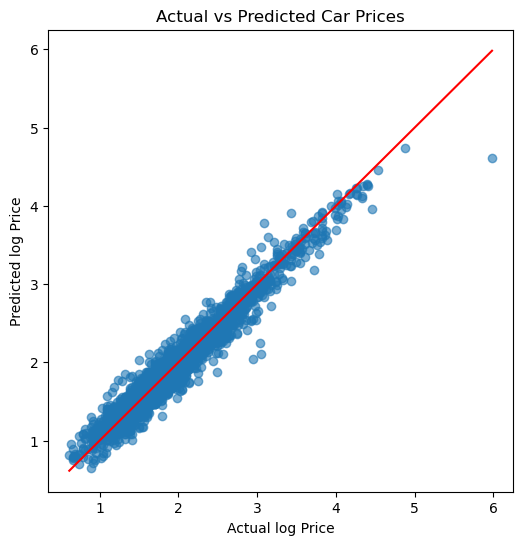

In [88]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual log Price")
plt.ylabel("Predicted log Price")
plt.title("Actual vs Predicted Car Prices")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()